# Notebook 1 — Análisis Exploratorio (EDA)

**Proyecto:** Portfolio Data Analyst — E-Commerce Analysis  
**Dataset:** Kaggle E-Commerce Data · 541.909 filas · 8 columnas  
**Período:** Diciembre 2010 → Diciembre 2011

**Objetivo:** Conocer el dato crudo en profundidad — completitud, distribuciones, outliers, patrones y anomalías. Esta notebook no toma decisiones de transformación ni separación de tablas. Los descubrimientos documentados aquí son el insumo de la Notebook 2.

---
## Índice
1. [Setup](#1-setup)
2. [Carga y primera inspección](#2-carga)
3. [Completitud y perfilado de columnas](#3-perfilado)
4. [Valores nulos y patrón de ausencia](#4-nulos)
5. [Duplicados](#5-duplicados)
6. [Estadísticas descriptivas — variables numéricas](#6-estadisticas)
7. [Forma de distribución y sesgo](#7-distribucion)
8. [Outliers con validación de negocio](#8-outliers)
9. [Variables categóricas — frecuencia, cardinalidad y patrones temporales](#9-categoricas)
10. [Matriz de correlación](#10-correlacion)
11. [Consistencia de formatos y validación de negocio](#11-consistencia)
12. [Columnas redundantes](#12-redundantes)
13. [Conclusiones y descubrimientos del EDA](#13-conclusiones)

---
## 1. Setup <a id='1-setup'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

PALETTE = {
    'primary':   '#4C72B0',
    'secondary': '#DD8452',
    'accent':    '#55A868',
    'danger':    '#C44E52',
    'neutral':   '#8172B3'
}

os.makedirs('../assets/', exist_ok=True)
DATA_PATH = '../data/data.csv'

---
## 2. Carga y primera inspección <a id='2-carga'></a>

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin1')  # latin1: caracteres europeos en Description
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'Filas: {df.shape[0]:,} · Columnas: {df.shape[1]}')
print(f'Período: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()} ({(df["InvoiceDate"].max() - df["InvoiceDate"].min()).days} días)')

df.dtypes

Filas: 541,909 · Columnas: 8
Período: 2010-12-01 → 2011-12-09 (373 días)


InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


---
## 3. Completitud y perfilado de columnas <a id='3-perfilado'></a>

In [4]:
perfil = pd.DataFrame({
    'dtype':       df.dtypes,
    'nulos':       df.isnull().sum(),
    'nulos_%':     (df.isnull().sum() / len(df) * 100).round(2),
    'unicos':      df.nunique(),
    'ejemplo_1':   df.apply(lambda s: s.dropna().iloc[0]  if len(s.dropna()) > 0 else None),
    'ejemplo_2':   df.apply(lambda s: s.dropna().iloc[10] if len(s.dropna()) > 10 else None),
})

perfil

,dtype,nulos,nulos_%,unicos,ejemplo_1,ejemplo_2
InvoiceNo,object,0,0.00,25900,536365,536367
StockCode,object,0,0.00,4070,85123A,22745
Description,object,1454,0.27,4223,WHITE HANGING HEART T-LIGHT HOLDER,POPPY'S PLAYHOUSE BEDROOM
Quantity,int64,0,0.00,722,6,6
InvoiceDate,datetime64[ns],0,0.00,23260,2010-12-01 08:26:00,2010-12-01 08:34:00
UnitPrice,float64,0,0.00,1630,2.55,2.1
CustomerID,float64,135080,24.93,4372,17850.0,13047.0
Country,object,0,0.00,38,United Kingdom,United Kingdom


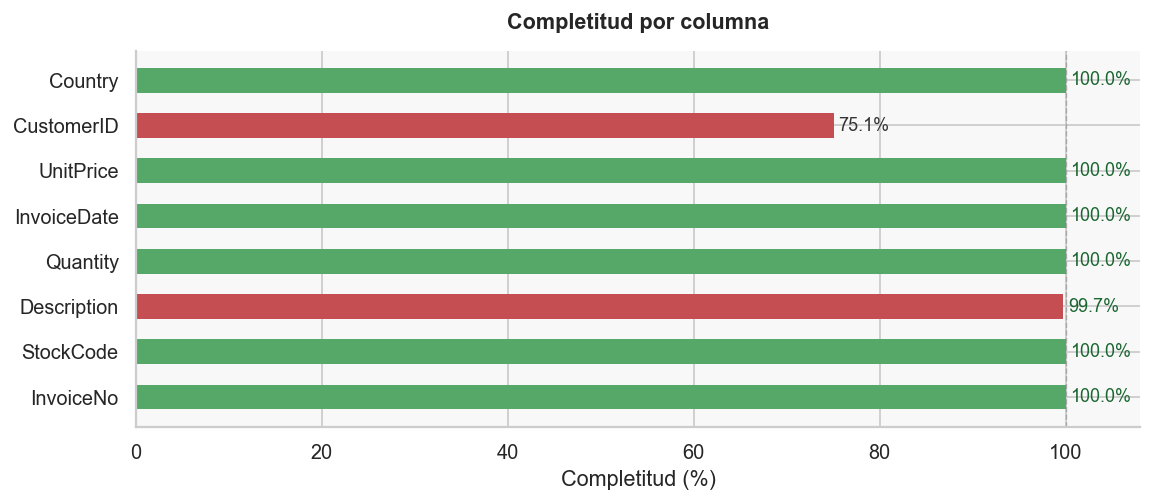

In [5]:
completitud = (1 - df.isnull().mean()) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(completitud.index, completitud.values,
               color=[PALETTE['accent'] if v == 100 else PALETTE['danger'] for v in completitud.values],
               edgecolor='none', height=0.55)
for bar, val in zip(bars, completitud.values):
    ax.text(min(val + 0.5, 101), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color='#333' if val < 99 else '#1a6630')
ax.set_xlim(0, 108)
ax.axvline(100, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Completitud (%)')
ax.set_title('Completitud por columna', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../assets/01_completitud.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 4. Valores nulos y patrón de ausencia <a id='4-nulos'></a>

In [6]:
nulos_df = pd.DataFrame({
    'Nulos':   df.isnull().sum(),
    'Pct (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0')

nulos_df

,Nulos,Pct (%)
Description,1454,0.27
CustomerID,135080,24.93


In [7]:
ambos_null   = df[df['CustomerID'].isna() & df['Description'].isna()]
solo_cust    = df[df['CustomerID'].isna() & df['Description'].notna()]
solo_desc    = df[df['CustomerID'].notna() & df['Description'].isna()]
ninguno_null = df[df['CustomerID'].notna() & df['Description'].notna()]

pattern = pd.DataFrame({
    'Patrón': ['CID=NULL · Desc=NULL', 'CID=NULL · Desc=OK',
               'CID=OK · Desc=NULL', 'Ambos completos'],
    'Filas':  [len(ambos_null), len(solo_cust), len(solo_desc), len(ninguno_null)],
    'Pct (%)': [round(len(x)/len(df)*100, 2)
                for x in [ambos_null, solo_cust, solo_desc, ninguno_null]],
})

pattern

,Patrón,Filas,Pct (%)
0,CID=NULL · Desc=NULL,1454,0.27
1,CID=NULL · Desc=OK,133626,24.66
2,CID=OK · Desc=NULL,0,0.00
3,Ambos completos,406829,75.07


Cuando Description es nula, CustomerID es nulo el 100% de las veces. La relación no es simétrica — CustomerID puede ser nulo con Description presente (133.626 filas).

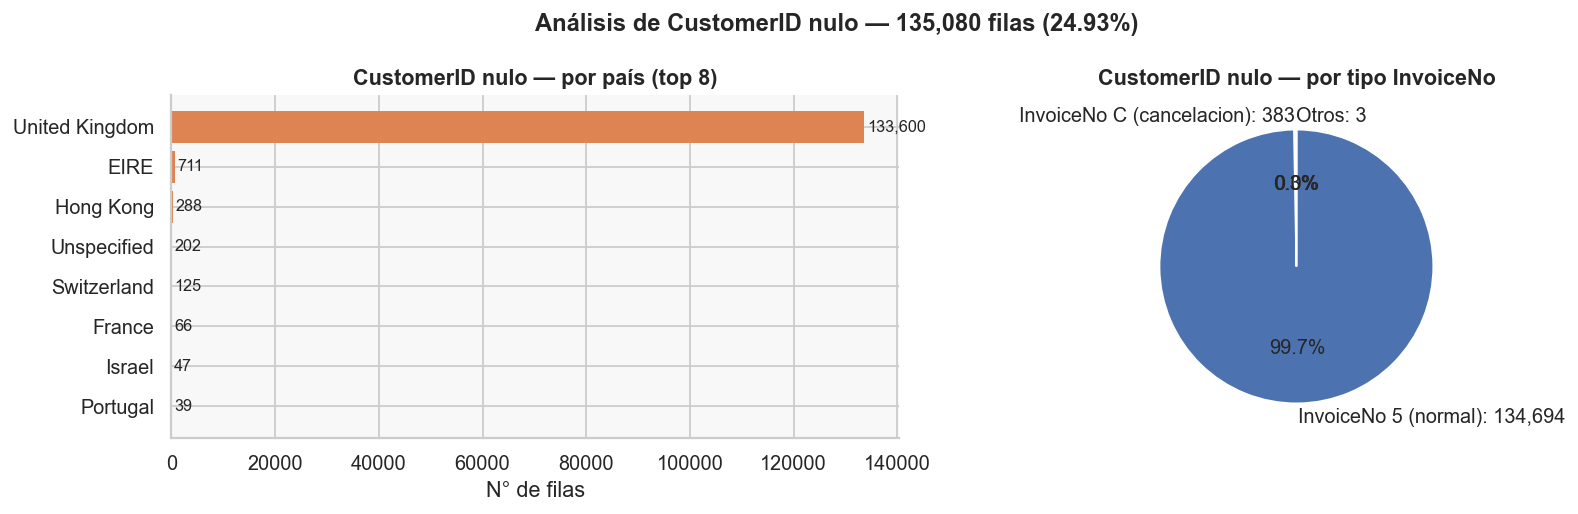

In [8]:
null_cust = df[df['CustomerID'].isna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

top_paises_null = null_cust['Country'].value_counts().head(8)
axes[0].barh(top_paises_null.index[::-1], top_paises_null.values[::-1],
             color=PALETTE['secondary'], edgecolor='none')
axes[0].set_title('CustomerID nulo — por país (top 8)', fontweight='bold')
axes[0].set_xlabel('N° de filas')
for bar, val in zip(axes[0].patches, top_paises_null.values[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

invoice_type = null_cust['InvoiceNo'].astype(str).str[0].value_counts()
labels_inv = [f'InvoiceNo C (cancelacion): {invoice_type.get("C",0):,}',
              f'InvoiceNo 5 (normal): {invoice_type.get("5",0):,}',
              f'Otros: {sum(v for k,v in invoice_type.items() if k not in ["C","5"]):,}']
sizes = [invoice_type.get("C",0), invoice_type.get("5",0),
         sum(v for k,v in invoice_type.items() if k not in ["C","5"])]
axes[1].pie([s for s in sizes if s > 0],
            labels=[l for l, s in zip(labels_inv, sizes) if s > 0],
            colors=[PALETTE['danger'], PALETTE['primary'], PALETTE['neutral']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('CustomerID nulo — por tipo InvoiceNo', fontweight='bold')

plt.suptitle(f'Análisis de CustomerID nulo — {len(null_cust):,} filas ({len(null_cust)/len(df)*100:.2f}%)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_nulos_cid.png', dpi=130, bbox_inches='tight')
plt.show()

El 98.90% de los CustomerID nulos corresponden a United Kingdom. Son ventas reales sin cliente identificado, no errores de carga.

---
## 5. Duplicados <a id='5-duplicados'></a>

In [9]:
dups_total  = df.duplicated().sum()
dups_inv_sc = df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

print(f'Duplicados exactos (todas las columnas): {dups_total:,} ({dups_total/len(df)*100:.2f}%)')
print(f'Duplicados InvoiceNo+StockCode: {dups_inv_sc:,} ({dups_inv_sc/len(df)*100:.2f}%)')

df[df.duplicated(keep=False)].sort_values(['InvoiceNo','StockCode']).head(8)

Duplicados exactos (todas las columnas): 5,268 (0.97%)
Duplicados InvoiceNo+StockCode: 10,684 (1.97%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom


In [10]:
multi = (df.groupby(['InvoiceNo','StockCode']).size()
           .reset_index(name='count')
           .query('count > 1')
           .sort_values('count', ascending=False))

print(f'Pares InvoiceNo+StockCode con más de 1 línea: {len(multi):,}')
print(f'Máximo de repeticiones para un par: {multi["count"].max()}')

multi.head(10)

Pares InvoiceNo+StockCode con más de 1 línea: 9,694
Máximo de repeticiones para un par: 20


,InvoiceNo,StockCode,count
205912,555524,22698,20
523861,C544580,S,16
205911,555524,22697,12
405243,572861,22775,8
399764,572344,M,7
525477,C553531,S,7
477198,578289,23395,7
523863,C544583,S,7
47688,540524,21756,6
56766,541266,21754,6


Los duplicados exactos deben eliminarse en ETL. Los duplicados InvoiceNo+StockCode con distinta Quantity o UnitPrice pueden ser ajustes de pedido legítimos — revisar caso por caso en ETL.

---
## 6. Estadísticas descriptivas — variables numéricas <a id='6-estadisticas'></a>

In [11]:
desc = df[['Quantity', 'UnitPrice']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
desc.loc['skewness'] = df[['Quantity', 'UnitPrice']].skew()
desc.loc['kurtosis'] = df[['Quantity', 'UnitPrice']].kurtosis()
desc.loc['cv (%)']   = (df[['Quantity', 'UnitPrice']].std() /
                        df[['Quantity', 'UnitPrice']].mean() * 100).round(2)

desc.round(4)

,Quantity,UnitPrice
count,541909.0000,541909.0000
mean,9.5522,4.6111
std,218.0812,96.7599
min,-80995.0000,-11062.0600
1%,-2.0000,0.1900
5%,1.0000,0.4200
25%,1.0000,1.2500
50%,3.0000,2.0800
75%,10.0000,4.1300
95%,29.0000,9.9500


In [12]:
df_sales = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['InvoiceNo'].astype(str).str.startswith('C')) &
    (df['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$', na=False))
].copy()
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['UnitPrice']

rev_stats = df_sales['Revenue'].describe(percentiles=[.25, .5, .75, .95, .99])
rev_stats['sum']      = df_sales['Revenue'].sum()
rev_stats['skewness'] = df_sales['Revenue'].skew()

rev_stats.round(2)

count         527725.00
mean              19.46
std              268.61
min                0.06
25%                3.75
50%                9.90
75%               17.40
95%               58.50
99%              179.00
max           168469.60
sum         10271034.61
skewness         518.48
Name: Revenue, dtype: float64

---
## 7. Forma de distribución y sesgo <a id='7-distribucion'></a>

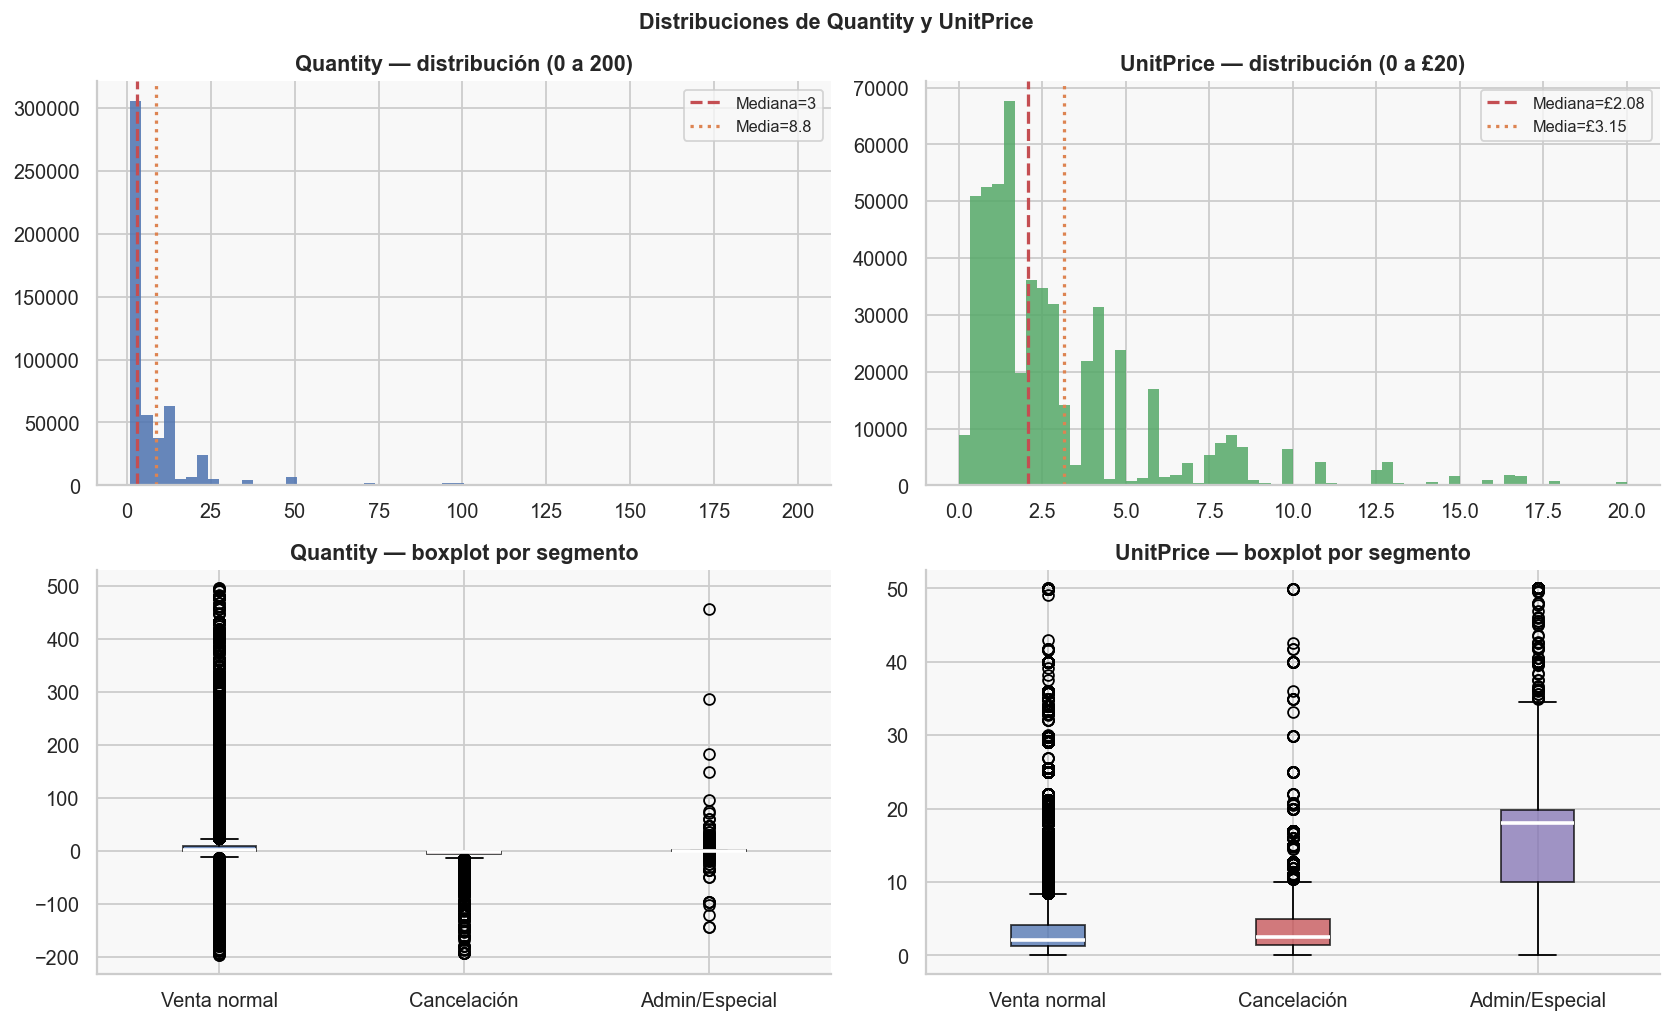

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

qty_pos = df[(df['Quantity'] > 0) & (df['Quantity'] <= 200)]['Quantity']
axes[0,0].hist(qty_pos, bins=60, color=PALETTE['primary'], edgecolor='none', alpha=0.85)
axes[0,0].set_title('Quantity — distribución (0 a 200)', fontweight='bold')
axes[0,0].axvline(qty_pos.median(), color=PALETTE['danger'], lw=1.8, ls='--', label=f'Mediana={qty_pos.median():.0f}')
axes[0,0].axvline(qty_pos.mean(),   color=PALETTE['secondary'], lw=1.8, ls=':',  label=f'Media={qty_pos.mean():.1f}')
axes[0,0].legend(fontsize=9)

price_pos = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)]['UnitPrice']
axes[0,1].hist(price_pos, bins=60, color=PALETTE['accent'], edgecolor='none', alpha=0.85)
axes[0,1].set_title('UnitPrice — distribución (0 a £20)', fontweight='bold')
axes[0,1].axvline(price_pos.median(), color=PALETTE['danger'], lw=1.8, ls='--', label=f'Mediana=£{price_pos.median():.2f}')
axes[0,1].axvline(price_pos.mean(),   color=PALETTE['secondary'], lw=1.8, ls=':',  label=f'Media=£{price_pos.mean():.2f}')
axes[0,1].legend(fontsize=9)

df['segmento'] = 'Venta normal'
df.loc[df['InvoiceNo'].astype(str).str.startswith('C'), 'segmento'] = 'Cancelación'
df.loc[~df['StockCode'].str.match(r'^\d{5}[A-Za-z]{0,2}$', na=False), 'segmento'] = 'Admin/Especial'

df_bx  = df[(df['Quantity'] > -200) & (df['Quantity'] < 500)]
orden  = ['Venta normal', 'Cancelación', 'Admin/Especial']
colores_bx = [PALETTE['primary'], PALETTE['danger'], PALETTE['neutral']]
data_q = [df_bx[df_bx['segmento']==s]['Quantity'].values for s in orden]
bp = axes[1,0].boxplot(data_q, tick_labels=orden, patch_artist=True,
                       medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], colores_bx):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1,0].set_title('Quantity — boxplot por segmento', fontweight='bold')

df_bx2 = df[(df['UnitPrice'] >= 0) & (df['UnitPrice'] <= 50)]
data_p = [df_bx2[df_bx2['segmento']==s]['UnitPrice'].values for s in orden]
bp2 = axes[1,1].boxplot(data_p, tick_labels=orden, patch_artist=True,
                        medianprops=dict(color='white', lw=2))
for patch, color in zip(bp2['boxes'], colores_bx):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1,1].set_title('UnitPrice — boxplot por segmento', fontweight='bold')

plt.suptitle('Distribuciones de Quantity y UnitPrice', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../assets/01_distribuciones.png', dpi=130, bbox_inches='tight')
plt.show()

df = df.drop(columns=['segmento'])

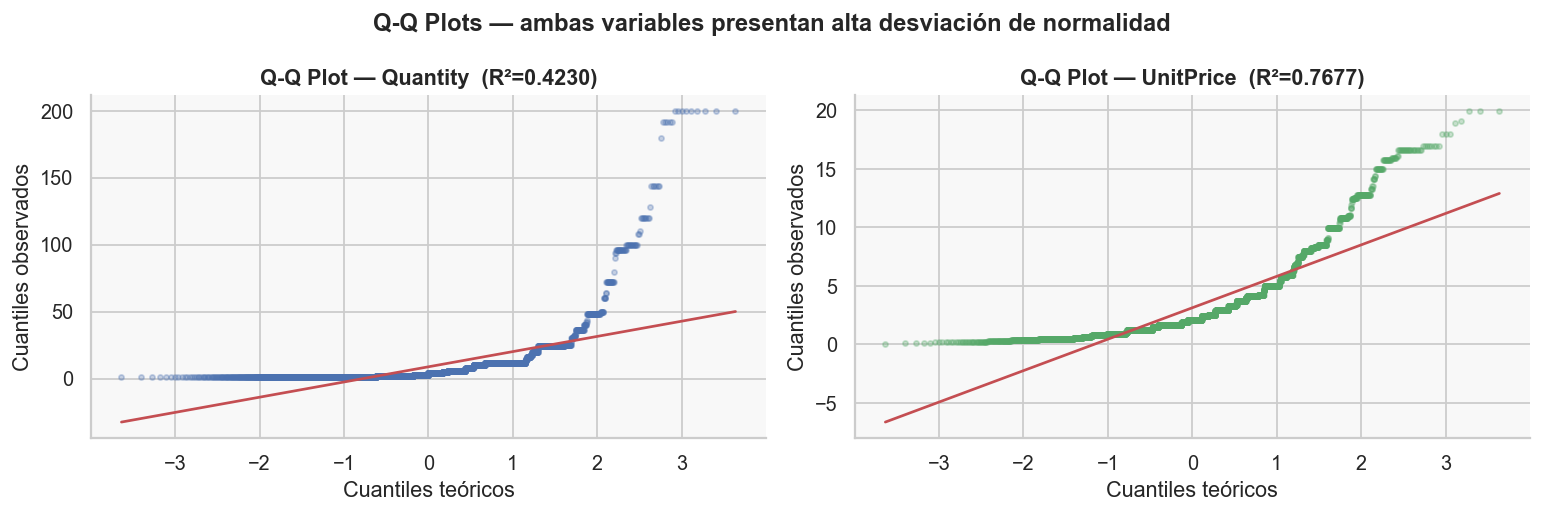

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

qty_sample   = df[(df['Quantity'] > 0) & (df['Quantity'] <= 200)]['Quantity'].sample(5000, random_state=42)
price_sample = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)]['UnitPrice'].sample(5000, random_state=42)

for ax, data, label, color in zip(
    axes, [qty_sample, price_sample], ['Quantity', 'UnitPrice'],
    [PALETTE['primary'], PALETTE['accent']]
):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.3, s=8)
    ax.plot(osm, slope * np.array(osm) + intercept, color=PALETTE['danger'], lw=1.5)
    ax.set_title(f'Q-Q Plot — {label}  (R²={r**2:.4f})', fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

plt.suptitle('Q-Q Plots — ambas variables presentan alta desviación de normalidad', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_qqplots.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 8. Outliers con validación de negocio <a id='8-outliers'></a>

In [15]:
def iqr_outliers(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = series[(series < lo) | (series > hi)]
    print(f'{label}:')
    print(f'  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}')
    print(f'  Límite inferior: {lo:.2f}  |  Límite superior: {hi:.2f}')
    print(f'  Outliers IQR: {len(out):,} ({len(out)/len(series)*100:.2f}%)')
    print(f'  Min: {series.min():,.2f}  |  Max: {series.max():,.2f}')
    print()

iqr_outliers(df['Quantity'],  'Quantity  (dataset completo)')
iqr_outliers(df['UnitPrice'], 'UnitPrice (dataset completo)')

Quantity  (dataset completo):
  Q1=1.00 | Q3=10.00 | IQR=9.00
  Límite inferior: -12.50  |  Límite superior: 23.50
  Outliers IQR: 58,619 (10.82%)
  Min: -80,995.00  |  Max: 80,995.00

UnitPrice (dataset completo):
  Q1=1.25 | Q3=4.13 | IQR=2.88
  Límite inferior: -3.07  |  Límite superior: 8.45
  Outliers IQR: 39,627 (7.31%)
  Min: -11,062.06  |  Max: 38,970.00



In [16]:
qty_muy_neg = df[df['Quantity'] < -1000].sort_values('Quantity')
print(f'Qty < -1.000: {len(qty_muy_neg)} filas')
display(qty_muy_neg[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID']].head(8))

qty_muy_pos = df[df['Quantity'] > 1000].sort_values('Quantity', ascending=False)
print(f'Qty > 1.000: {len(qty_muy_pos)} filas')
display(qty_muy_pos[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID']].head(8))

Qty < -1.000: 58 filas


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0
225530,556691,23005,printing smudges/thrown away,-9600,0.00,NaN
225529,556690,23005,printing smudges/thrown away,-9600,0.00,NaN
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03,15838.0
225528,556687,23003,Printing smudges/thrown away,-9058,0.00,NaN
115818,546152,72140F,throw away,-5368,0.00,NaN
431381,573596,79323W,"Unsaleable, destroyed.",-4830,0.00,NaN


Qty > 1.000: 116 filas


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,13256.0
74614,542504,37413,NaN,5568,0.00,NaN
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0
220843,556231,85123A,?,4000,0.00,NaN
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0


In [17]:
price_extremo = df[df['UnitPrice'] > 100].sort_values('UnitPrice', ascending=False)
print(f'UnitPrice > £100: {len(price_extremo)} filas')
display(price_extremo[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID']].head(10))

price_neg = df[df['UnitPrice'] < 0]
print(f'UnitPrice negativo: {len(price_neg)} filas')
if len(price_neg) > 0:
    display(price_neg[['InvoiceNo','StockCode','Description','Quantity','UnitPrice','CustomerID']])

UnitPrice > £100: 1036 filas


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
222681,C556445,M,Manual,-1,38970.00,15098.0
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46,NaN
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02,NaN
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71,NaN
16356,C537651,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,NaN
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33,NaN
16232,C537644,AMAZONFEE,AMAZON FEE,-1,13474.79,NaN
524601,C580604,AMAZONFEE,AMAZON FEE,-1,11586.50,NaN
299982,A563185,B,Adjust bad debt,1,11062.06,NaN


UnitPrice negativo: 2 filas


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN


In [18]:
outliers_resumen = pd.DataFrame([
    {'Categoría': 'Qty negativa — InvoiceNo C (cancelaciones)',
     'Filas': df[df['InvoiceNo'].astype(str).str.startswith('C') & (df['Quantity']<0)].shape[0],
     'Es anomalía': 'No — comportamiento esperado',
     'Acción ETL': 'Separar a tabla de cancelaciones'},
    {'Categoría': 'Qty negativa — sin InvoiceNo C (ajustes inventario)',
     'Filas': df[(df['Quantity']<0) & (~df['InvoiceNo'].astype(str).str.startswith('C'))].shape[0],
     'Es anomalía': 'No — ajuste interno de stock',
     'Acción ETL': 'Separar a inventory_adjustments'},
    {'Categoría': 'UnitPrice = 0',
     'Filas': df[df['UnitPrice']==0].shape[0],
     'Es anomalía': 'Parcial — notas operativas sin precio',
     'Acción ETL': 'Excluir del análisis de revenue'},
    {'Categoría': 'UnitPrice < 0',
     'Filas': df[df['UnitPrice']<0].shape[0],
     'Es anomalía': 'Sí — precios negativos sin explicación',
     'Acción ETL': 'Investigar y excluir'},
    {'Categoría': 'UnitPrice extremo (> £100 en admin)',
     'Filas': df[(df['UnitPrice']>100) & (~df['StockCode'].str.match(r"^\d{5}", na=False))].shape[0],
     'Es anomalía': 'No — ajustes contables (ej. M = Manual)',
     'Acción ETL': 'Mantener en dim_ajustes_contables'},
])

outliers_resumen

,Categoría,Filas,Es anomalía,Acción ETL
0,Qty negativa — InvoiceNo C (cancelaciones),9288,No — comportamiento esperado,Separar a tabla de cancelaciones
1,Qty negativa — sin InvoiceNo C (ajustes invent...,1336,No — ajuste interno de stock,Separar a inventory_adjustments
2,UnitPrice = 0,2515,Parcial — notas operativas sin precio,Excluir del análisis de revenue
3,UnitPrice < 0,2,Sí — precios negativos sin explicación,Investigar y excluir
4,UnitPrice extremo (> £100 en admin),904,No — ajustes contables (ej. M = Manual),Mantener en dim_ajustes_contables


---
## 9. Variables categóricas — frecuencia, cardinalidad y patrones temporales <a id='9-categoricas'></a>

In [19]:
cat_cols = ['InvoiceNo', 'StockCode', 'Description', 'Country']
card = pd.DataFrame({
    'Valores únicos':      [df[c].nunique() for c in cat_cols],
    'Valor más frecuente': [df[c].mode().iloc[0] if len(df[c].mode()) > 0 else None for c in cat_cols],
    'Frec. del modo':      [df[c].value_counts().iloc[0] for c in cat_cols],
    'Frec. modo (%)':      [(df[c].value_counts().iloc[0]/len(df)*100).round(2) for c in cat_cols],
}, index=cat_cols)

card

,Valores únicos,Valor más frecuente,Frec. del modo,Frec. modo (%)
InvoiceNo,25900,573585,1114,0.21
StockCode,4070,85123A,2313,0.43
Description,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,0.44
Country,38,United Kingdom,495478,91.43


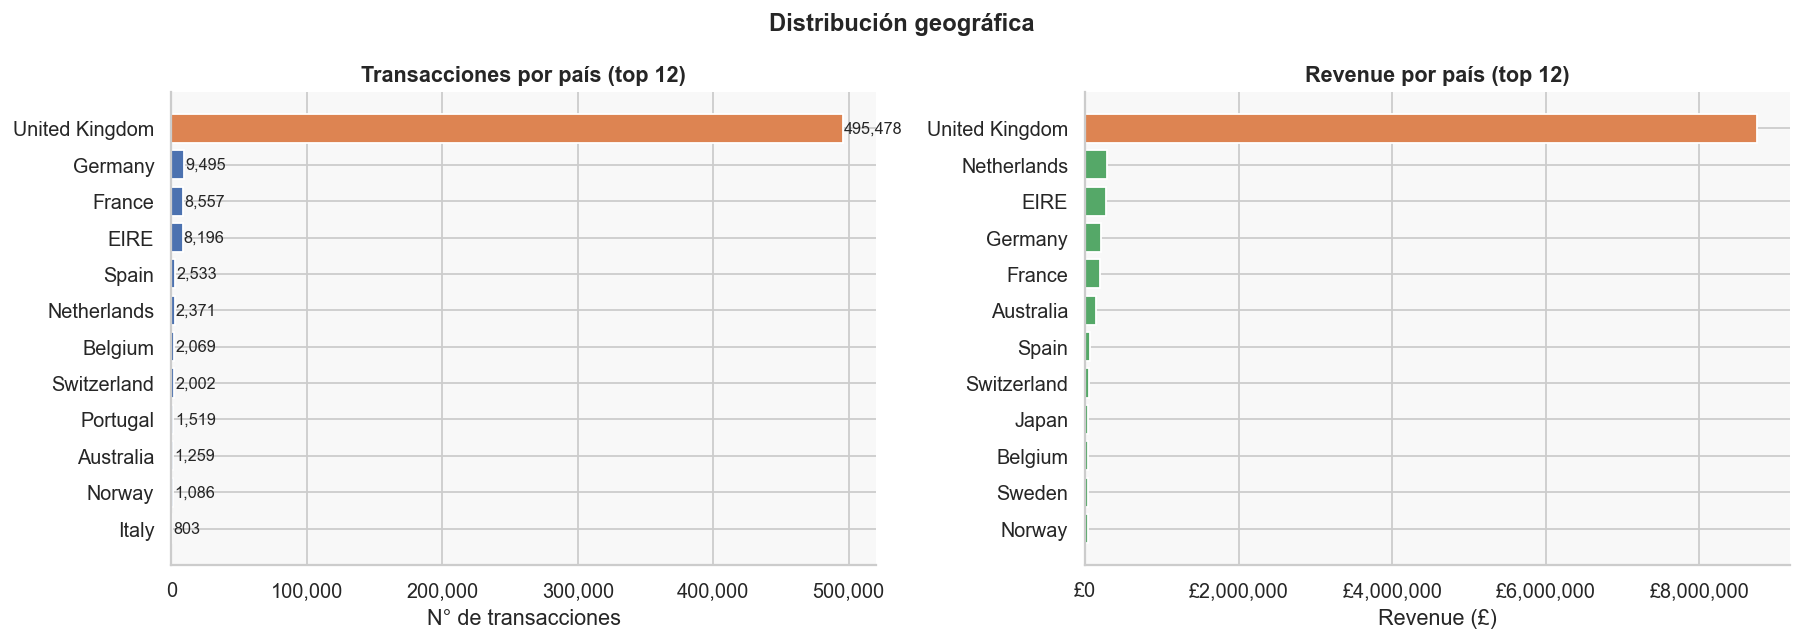

In [20]:
# Distribución por país
country_counts  = df['Country'].value_counts()
country_revenue = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_n = 12
top_c = country_counts.head(top_n)
axes[0].barh(top_c.index[::-1], top_c.values[::-1],
             color=[PALETTE['primary'] if c != 'United Kingdom' else PALETTE['secondary']
                    for c in top_c.index[::-1]])
axes[0].set_title(f'Transacciones por país (top {top_n})', fontweight='bold')
axes[0].set_xlabel('N° de transacciones')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(axes[0].patches, top_c.values[::-1]):
    axes[0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

top_r = country_revenue.head(top_n)
axes[1].barh(top_r.index[::-1], top_r.values[::-1],
             color=[PALETTE['accent'] if c != 'United Kingdom' else PALETTE['secondary']
                    for c in top_r.index[::-1]])
axes[1].set_title(f'Revenue por país (top {top_n})', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

plt.suptitle('Distribución geográfica', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_paises.png', dpi=130, bbox_inches='tight')
plt.show()

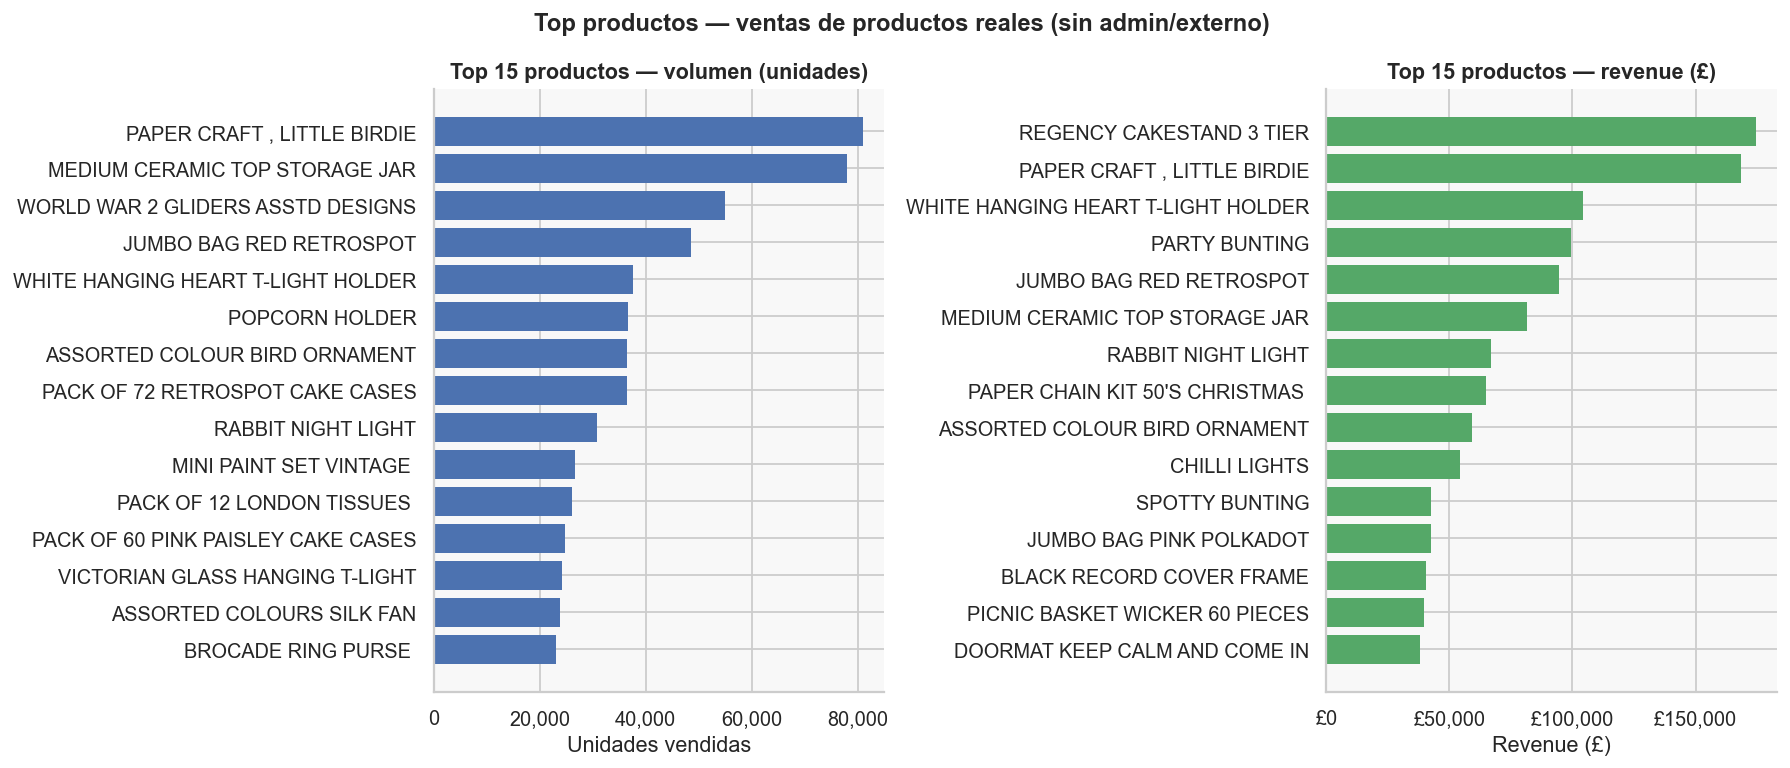

In [21]:
# Top productos por volumen y por revenue
prod_vol = (df_sales.groupby(['StockCode','Description'])['Quantity']
            .sum().sort_values(ascending=False).head(15).reset_index())
prod_rev = (df_sales.groupby(['StockCode','Description'])['Revenue']
            .sum().sort_values(ascending=False).head(15).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(prod_vol['Description'].str[:35][::-1], prod_vol['Quantity'][::-1],
             color=PALETTE['primary'], edgecolor='none')
axes[0].set_title('Top 15 productos — volumen (unidades)', fontweight='bold')
axes[0].set_xlabel('Unidades vendidas')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(prod_rev['Description'].str[:35][::-1], prod_rev['Revenue'][::-1],
             color=PALETTE['accent'], edgecolor='none')
axes[1].set_title('Top 15 productos — revenue (£)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

plt.suptitle('Top productos — ventas de productos reales (sin admin/externo)', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_top_productos.png', dpi=130, bbox_inches='tight')
plt.show()

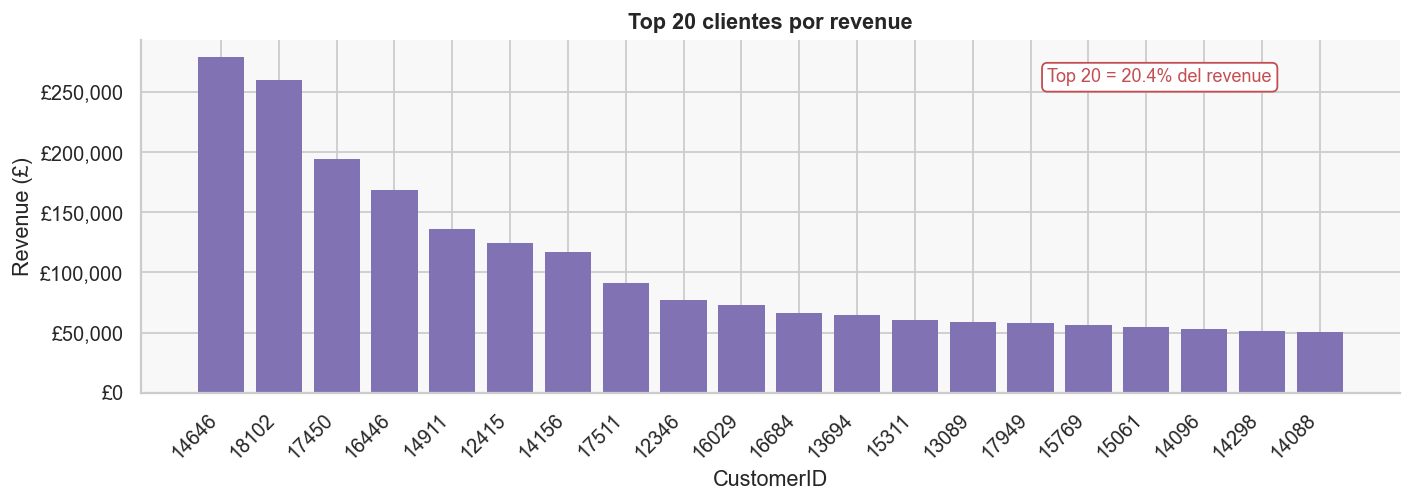

In [22]:
# Top clientes por revenue
top_clientes = (df_sales.groupby('CustomerID')['Revenue']
                .sum().sort_values(ascending=False).head(20))
top_clientes_pct = top_clientes.sum() / df_sales['Revenue'].sum() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top_clientes.index.astype(int).astype(str),
       top_clientes.values, color=PALETTE['neutral'], edgecolor='none')
ax.set_title('Top 20 clientes por revenue', fontweight='bold')
ax.set_xlabel('CustomerID')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))
plt.xticks(rotation=45, ha='right')
ax.text(0.72, 0.88, f'Top 20 = {top_clientes_pct:.1f}% del revenue',
        transform=ax.transAxes, fontsize=10, color=PALETTE['danger'],
        bbox=dict(facecolor='white', edgecolor=PALETTE['danger'], boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.savefig('../assets/01_top_clientes.png', dpi=130, bbox_inches='tight')
plt.show()

### 9.5 Patrones temporales — estacionalidad, día de semana y hora

C:\Users\mike7\AppData\Local\Temp\ipykernel_1956\2069196881.py:23: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mike7\AppData\Local\Temp\ipykernel_1956\2069196881.py:24: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../assets/01_temporal_mensual.png', dpi=130, bbox_inches='tight')
c:\Users\mike7\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


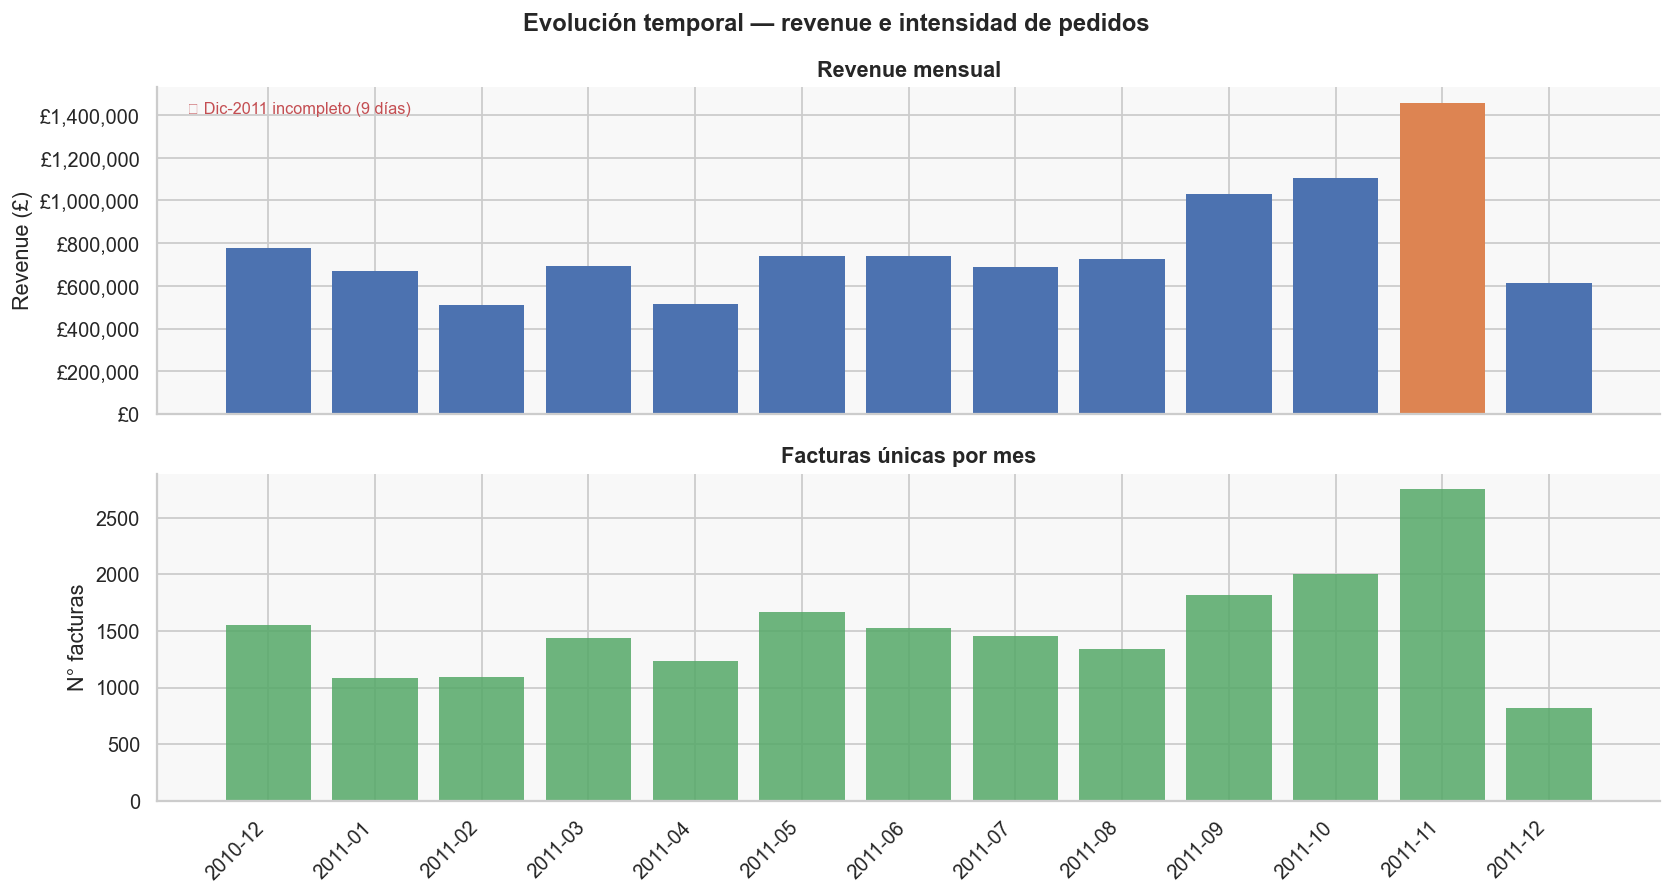

In [23]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_rev = df_sales.groupby('YearMonth')['Revenue'].sum()
monthly_inv = df_sales.groupby('YearMonth')['InvoiceNo'].nunique()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
x = range(len(monthly_rev))
labels_m = [str(p) for p in monthly_rev.index]

axes[0].bar(x, monthly_rev.values,
            color=[PALETTE['secondary'] if v == monthly_rev.max() else PALETTE['primary']
                   for v in monthly_rev.values], edgecolor='none')
axes[0].set_title('Revenue mensual', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'£{int(y):,}'))
axes[0].text(0.02, 0.92, '⚠ Dic-2011 incompleto (9 días)',
             transform=axes[0].transAxes, fontsize=9, color=PALETTE['danger'])

axes[1].bar(x, monthly_inv.values, color=PALETTE['accent'], edgecolor='none', alpha=0.85)
axes[1].set_title('Facturas únicas por mes', fontweight='bold')
axes[1].set_ylabel('N° facturas')
plt.xticks(list(x), labels_m, rotation=45, ha='right')
plt.suptitle('Evolución temporal — revenue e intensidad de pedidos', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_temporal_mensual.png', dpi=130, bbox_inches='tight')
plt.show()

C:\Users\mike7\AppData\Local\Temp\ipykernel_1956\71200426.py:23: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\mike7\AppData\Local\Temp\ipykernel_1956\71200426.py:24: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('../assets/01_temporal_dia_hora.png', dpi=130, bbox_inches='tight')
c:\Users\mike7\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


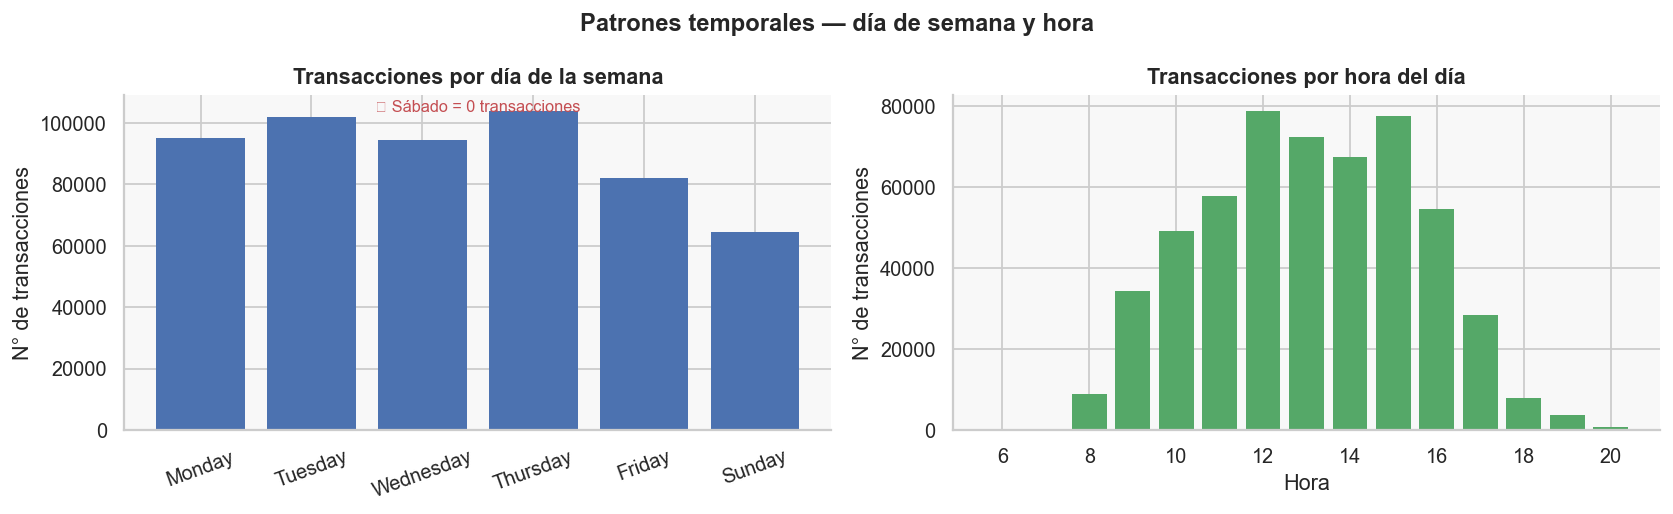

In [24]:
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour']    = df['InvoiceDate'].dt.hour

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
wday_counts   = df[df['Weekday'].isin(weekday_order)]['Weekday'].value_counts().reindex(weekday_order)
hour_counts   = df.groupby('Hour').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(wday_counts.index, wday_counts.values, color=PALETTE['primary'], edgecolor='none')
axes[0].set_title('Transacciones por día de la semana', fontweight='bold')
axes[0].set_ylabel('N° de transacciones')
axes[0].tick_params(axis='x', rotation=20)
axes[0].text(0.5, 0.95, '⚠ Sábado = 0 transacciones',
             transform=axes[0].transAxes, ha='center', fontsize=9, color=PALETTE['danger'])

axes[1].bar(hour_counts.index, hour_counts.values, color=PALETTE['accent'], edgecolor='none')
axes[1].set_title('Transacciones por hora del día', fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('N° de transacciones')

plt.suptitle('Patrones temporales — día de semana y hora', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_temporal_dia_hora.png', dpi=130, bbox_inches='tight')
plt.show()

df = df.drop(columns=['Weekday', 'Hour'])

Sin actividad los sábados — el negocio no opera ese día. Pico de actividad: martes a jueves, entre las 10:00 y las 15:00 hs.

---
## 10. Matriz de correlación <a id='10-correlacion'></a>

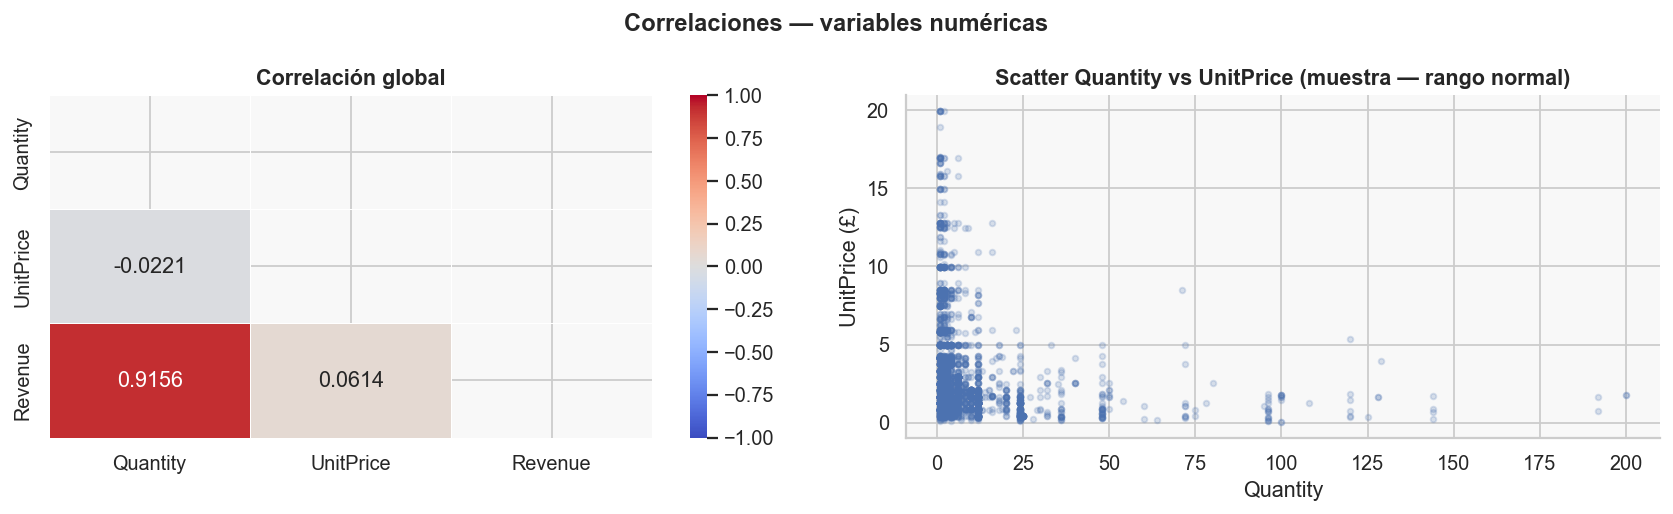

In [25]:
corr_df = df_sales[['Quantity','UnitPrice','Revenue']].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, ax=axes[0], annot=True, fmt='.4f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, mask=mask, annot_kws={'size': 12})
axes[0].set_title('Correlación global', fontweight='bold')

sample = df_sales[(df_sales['Quantity'] <= 200) & (df_sales['UnitPrice'] <= 20)].sample(3000, random_state=42)
axes[1].scatter(sample['Quantity'], sample['UnitPrice'],
                alpha=0.2, color=PALETTE['primary'], s=10)
axes[1].set_title('Scatter Quantity vs UnitPrice (muestra — rango normal)', fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('UnitPrice (£)')

plt.suptitle('Correlaciones — variables numéricas', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_correlacion.png', dpi=130, bbox_inches='tight')
plt.show()

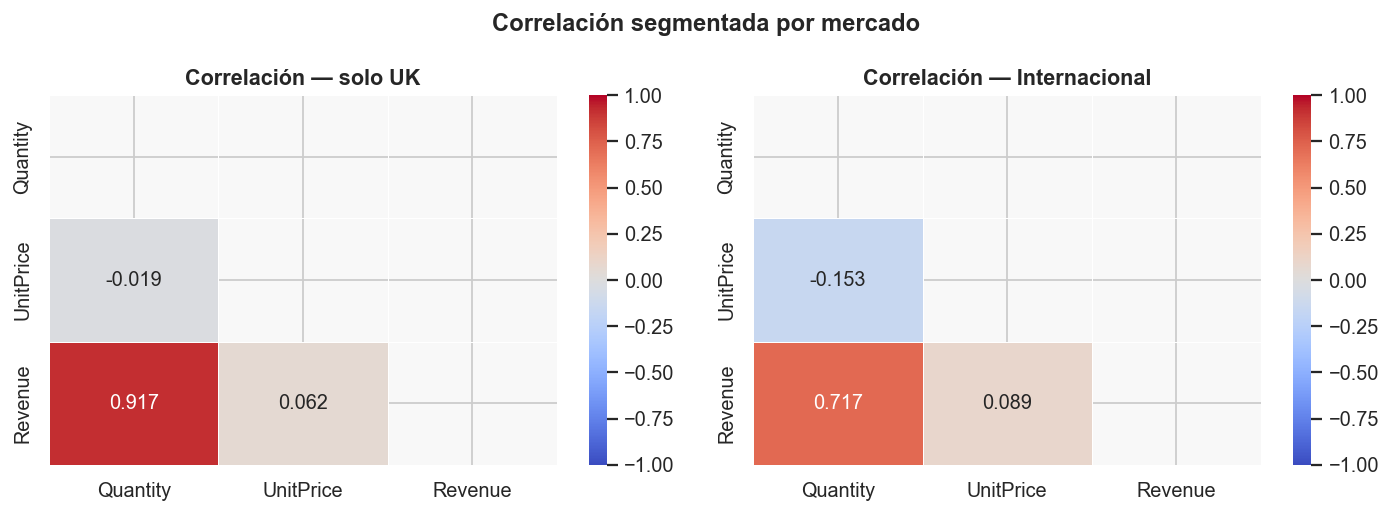

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, country_filter, title in zip(
    axes, ['United Kingdom', None],
    ['Correlación — solo UK', 'Correlación — Internacional']
):
    seg = df_sales[df_sales['Country'] == country_filter] if country_filter \
          else df_sales[df_sales['Country'] != 'United Kingdom']
    corr_seg = seg[['Quantity','UnitPrice','Revenue']].corr()
    mask_seg = np.triu(np.ones_like(corr_seg, dtype=bool))
    sns.heatmap(corr_seg, ax=ax, annot=True, fmt='.3f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                linewidths=0.5, mask=mask_seg, annot_kws={'size': 11})
    ax.set_title(title, fontweight='bold')

plt.suptitle('Correlación segmentada por mercado', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_correlacion_segmentada.png', dpi=130, bbox_inches='tight')
plt.show()

La correlación UnitPrice–Quantity es negativa leve en UK y positiva en Internacional. Internacional incluye mayoristas (NL, AU) con alto precio y alta cantidad.

---
## 11. Consistencia de formatos y validación de negocio <a id='11-consistencia'></a>

In [27]:
mask_ok  = df['InvoiceNo'].astype(str).str.match(r'^[C]?\d{6}$')
mask_esp = df['InvoiceNo'].astype(str).str.match(r'^[A]\d+$')
print(f'[1] InvoiceNo formato normal (nnnnnn o Cnnnnnn): {mask_ok.sum():,}')
print(f'[1] InvoiceNo formato especial (Annnnnn):        {mask_esp.sum():,}')
print(f'[1] InvoiceNo otros formatos:                    {(~mask_ok & ~mask_esp).sum():,}')

print(f'\n[2] CustomerID dtype: {df["CustomerID"].dtype}')
print(f'    → Almacenado como float64 pero representa enteros. Normalizar a Int64 en ETL.')

cancel_pos = df[df['InvoiceNo'].astype(str).str.startswith('C') & (df['Quantity'] > 0)]
print(f'\n[3] Cancelaciones (C) con Quantity POSITIVA: {len(cancel_pos)}')
if len(cancel_pos) > 0:
    display(cancel_pos[['InvoiceNo','StockCode','Quantity','UnitPrice','CustomerID']].head(5))
    print('    → Pueden ser correcciones de cancelaciones erróneas — revisar en ETL.')

lower_sc = df[df['StockCode'].str.match(r'^\d{5}[a-z]{1,2}$', na=False)]
print(f'\n[4] StockCode con sufijo en minúscula: {lower_sc["StockCode"].nunique()} SC únicos — {len(lower_sc):,} filas')
print(f'    → Son el mismo producto que su par en mayúscula. Normalizar con .str.upper() en ETL.')

lower_sc[['StockCode','Description']].drop_duplicates('StockCode').head(5)

[1] InvoiceNo formato normal (nnnnnn o Cnnnnnn): 541,906
[1] InvoiceNo formato especial (Annnnnn):        3
[1] InvoiceNo otros formatos:                    0

[2] CustomerID dtype: float64
    → Almacenado como float64 pero representa enteros. Normalizar a Int64 en ETL.

[3] Cancelaciones (C) con Quantity POSITIVA: 0

[4] StockCode con sufijo en minúscula: 111 SC únicos — 1,942 filas
    → Son el mismo producto que su par en mayúscula. Normalizar con .str.upper() en ETL.


,StockCode,Description
5370,15056bl,EDWARDIAN PARASOL BLACK
5371,15056p,EDWARDIAN PARASOL PINK
5438,47566b,TEA TIME PARTY BUNTING
5439,72349b,SET/6 PURPLE BUTTERFLY T-LIGHTS
5443,84872a,TEATIME FUNKY FLOWER BACKPACK FOR 2


---
## 12. Columnas redundantes <a id='12-redundantes'></a>

In [28]:
derivadas = pd.DataFrame([
    {'Columna':  'Revenue',
     'Tipo':     'Nueva (calculada)',
     'Fórmula':  'Quantity × UnitPrice',
     'Propósito':'Métrica principal de análisis financiero'},
    {'Columna':  'IsCancellation',
     'Tipo':     'Nueva (flag)',
     'Fórmula':  'InvoiceNo.startswith("C")',
     'Propósito':'Separar cancelaciones de ventas'},
    {'Columna':  'IsProduct',
     'Tipo':     'Nueva (flag)',
     'Fórmula':  'StockCode regex ^\\d{5}[A-Za-z]{0,2}$',
     'Propósito':'Separar productos reales de admin/externo'},
    {'Columna':  'Year / Month / DayOfWeek / Hour',
     'Tipo':     'Nueva (extraída)',
     'Fórmula':  'InvoiceDate.dt.*',
     'Propósito':'Análisis temporal granular'},
    {'Columna':  'CustomerID_clean',
     'Tipo':     'Transformada',
     'Fórmula':  'float64 → Int64 (nulos como NA)',
     'Propósito':'Tipo correcto para claves y joins'},
    {'Columna':  'sc_base',
     'Tipo':     'Nueva (extraída)',
     'Fórmula':  'StockCode[:5]',
     'Propósito':'Agrupar variantes del mismo producto'},
])

derivadas

,Columna,Tipo,Fórmula,Propósito
0,Revenue,Nueva (calculada),Quantity × UnitPrice,Métrica principal de análisis financiero
1,IsCancellation,Nueva (flag),"InvoiceNo.startswith(""C"")",Separar cancelaciones de ventas
2,IsProduct,Nueva (flag),"StockCode regex ^\d{5}[A-Za-z]{0,2}$",Separar productos reales de admin/externo
3,Year / Month / DayOfWeek / Hour,Nueva (extraída),InvoiceDate.dt.*,Análisis temporal granular
4,CustomerID_clean,Transformada,float64 → Int64 (nulos como NA),Tipo correcto para claves y joins
5,sc_base,Nueva (extraída),StockCode[:5],Agrupar variantes del mismo producto


Columnas sin redundancia directa: las 8 originales aportan información única. Description tiene alta correlación con StockCode (1 SC → 1 descripción canónica) pero no puede eliminarse — es la etiqueta legible del producto.

---
## 13. Conclusiones y descubrimientos del EDA <a id='13-conclusiones'></a>

In [29]:
hallazgos = pd.DataFrame([
    {
        'ID':        'F-01',
        'Hallazgo':  'El dataset mezcla fuentes con lógicas de negocio distintas',
        'Dato concreto': '3 patrones de StockCode (numérico / palabra clave / prefijo) con perfiles de nulos radicalmente distintos',
        'Severidad': 'ALTA'
    },
    {
        'ID':        'F-02',
        'Hallazgo':  'CustomerID nulo en casi 1 de cada 4 filas',
        'Dato concreto': '135.080 filas (24.93%) sin CustomerID — 98.9% corresponden a United Kingdom',
        'Severidad': 'ALTA'
    },
    {
        'ID':        'F-03',
        'Hallazgo':  '5.268 duplicados exactos en el dataset',
        'Dato concreto': '0.97% del total — mismo InvoiceNo, StockCode, Quantity, UnitPrice y CustomerID',
        'Severidad': 'ALTA'
    },
    {
        'ID':        'F-04',
        'Hallazgo':  'CustomerID almacenado como float64 cuando debería ser entero',
        'Dato concreto': 'Todos los valores terminan en .0 — CustomerID es un identificador, no una magnitud continua',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-05',
        'Hallazgo':  'StockCode con sufijos en minúscula — variantes del mismo producto',
        'Dato concreto': '111 StockCodes únicos afectados (ej: 85049a debería ser 85049A)',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-06',
        'Hallazgo':  'Quantity y UnitPrice tienen distribuciones fuertemente no normales',
        'Dato concreto': f'Quantity: skewness={df["Quantity"].skew():.1f}, CV={df["Quantity"].std()/df["Quantity"].mean()*100:.0f}%. UnitPrice: skewness={df["UnitPrice"].skew():.1f}. No usar media aritmética directamente.',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-07',
        'Hallazgo':  'Sin actividad comercial los sábados — patrón absoluto',
        'Dato concreto': '0 transacciones registradas en sábados en todo el período de 13 meses',
        'Severidad': 'BAJA'
    },
    {
        'ID':        'F-08',
        'Hallazgo':  'Diciembre 2011 es un mes incompleto — no comparable',
        'Dato concreto': 'Solo 8 días con datos en dic-2011 vs 26-27 días con datos en el resto de meses',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-09',
        'Hallazgo':  '2 filas con UnitPrice negativo',
        'Dato concreto': 'UnitPrice = -£11.062 — posible error de carga o asiento contable especial',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-10',
        'Hallazgo':  'Description tiene múltiples valores por StockCode',
        'Dato concreto': f'{(df.groupby("StockCode")["Description"].nunique() > 1).sum():,} StockCodes con más de 1 descripción — las extra son notas operativas, no variantes reales',
        'Severidad': 'MEDIA'
    },
    {
        'ID':        'F-11',
        'Hallazgo':  'Revenue de ventas anónimas es económicamente significativo',
        'Dato concreto': f'Las {df["CustomerID"].isna().sum():,} filas sin CustomerID incluyen ventas reales con UnitPrice > 0 — no son errores descartables',
        'Severidad': 'BAJA'
    },
    {
        'ID':        'F-12',
        'Hallazgo':  'Estacionalidad marcada con pico visible en Q4',
        'Dato concreto': 'Nov-2011 es el mes de mayor actividad del período — patrón consistente con retail de temporada',
        'Severidad': 'BAJA'
    },
])

hallazgos

,ID,Hallazgo,Dato concreto,Severidad
0,F-01,El dataset mezcla fuentes con lógicas de negoc...,3 patrones de StockCode (numérico / palabra cl...,ALTA
1,F-02,CustomerID nulo en casi 1 de cada 4 filas,135.080 filas (24.93%) sin CustomerID — 98.9% ...,ALTA
2,F-03,5.268 duplicados exactos en el dataset,"0.97% del total — mismo InvoiceNo, StockCode, ...",ALTA
3,F-04,CustomerID almacenado como float64 cuando debe...,Todos los valores terminan en .0 — CustomerID ...,MEDIA
4,F-05,StockCode con sufijos en minúscula — variantes...,111 StockCodes únicos afectados (ej: 85049a de...,MEDIA
5,F-06,Quantity y UnitPrice tienen distribuciones fue...,"Quantity: skewness=-0.3, CV=2283%. UnitPrice: ...",MEDIA
6,F-07,Sin actividad comercial los sábados — patrón a...,0 transacciones registradas en sábados en todo...,BAJA
7,F-08,Diciembre 2011 es un mes incompleto — no compa...,Solo 8 días con datos en dic-2011 vs 26-27 día...,MEDIA
8,F-09,2 filas con UnitPrice negativo,UnitPrice = -£11.062 — posible error de carga ...,MEDIA
9,F-10,Description tiene múltiples valores por StockCode,650 StockCodes con más de 1 descripción — las ...,MEDIA


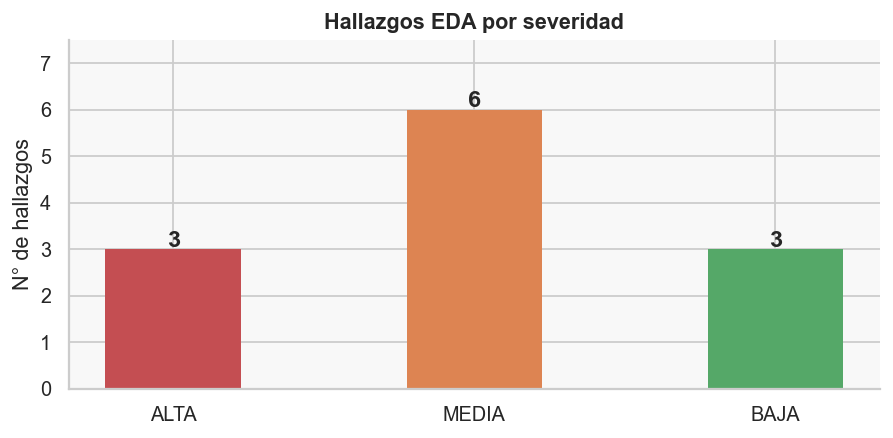

In [30]:
sev_series = hallazgos['Severidad'].value_counts().reindex(['ALTA', 'MEDIA', 'BAJA'], fill_value=0)
sev_colors = [PALETTE['danger'], PALETTE['secondary'], PALETTE['accent']]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(sev_series.index, sev_series.values, color=sev_colors, edgecolor='none', width=0.45)
for bar, val in zip(bars, sev_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', fontsize=13, fontweight='bold')
ax.set_title('Hallazgos EDA por severidad', fontweight='bold')
ax.set_ylabel('N° de hallazgos')
ax.set_ylim(0, sev_series.max() + 1.5)
plt.tight_layout()
plt.savefig('../assets/01_hallazgos_severidad.png', dpi=130, bbox_inches='tight')
plt.show()

3 hallazgos de severidad ALTA requieren atención antes de cualquier análisis posterior.

### CONCLUSIONES DEL ANALISIS

#### Calidad del dato
El dataset presenta **tres problemas críticos** que condicionan cualquier análisis posterior: mezcla de fuentes con lógicas distintas (F-01), un cuarto de las filas sin CustomerID identificado (F-02) y casi 5.300 registros duplicados exactos (F-03). Ninguno de estos problemas invalida el dataset — todos tienen una explicación de negocio — pero ninguno puede ignorarse.

A nivel de tipos de dato, CustomerID está almacenado como `float64` cuando su naturaleza es de identificador entero (F-04), y un subconjunto de StockCodes usa sufijos en minúscula que duplican artificialmente el catálogo de productos (F-05).

#### Estructura y distribuciones
Tanto Quantity como UnitPrice muestran distribuciones fuertemente sesgadas hacia la derecha con coeficientes de variación extremos (F-06). La media aritmética no es una medida representativa en este dataset — los análisis descriptivos deben apoyarse en medianas y percentiles. Los valores extremos en ambas variables no son errores: responden a lógicas de negocio identificables (mayoristas con alto volumen, ajustes contables con precios muy altos).

#### Patrones de negocio
El análisis temporal revela dos hallazgos sin ambigüedad: los sábados tienen actividad cero en todo el período (F-07) y diciembre 2011 es un mes truncado de solo 9 días que no puede compararse directamente con el resto (F-08). El patrón de actividad semanal se concentra de martes a jueves entre las 10:00 y las 15:00 horas.

La distribución geográfica está dominada por United Kingdom (~91% de las transacciones), pero el mercado internacional muestra tickets promedio significativamente más altos — señal de presencia de mayoristas internacionales que merecen tratamiento diferenciado en el análisis de clientes.

La estacionalidad es visible aunque no concluyente en el EDA: noviembre 2011 es el mes de mayor actividad (F-12), consistente con el patrón retail de Q4.

#### Señales para la Notebook 2
Los hallazgos F-01, F-02 y F-10 no son problemas de calidad del dato en sentido estricto — son evidencia de que el archivo original combina múltiples fuentes de datos con lógicas de negocio distintas. Description tiene múltiples valores por StockCode (F-10) porque algunas filas contienen notas operativas internas, no nombres de producto. CustomerID está ausente en patrones no aleatorios (F-02) porque responde al tipo de transacción, no a un error de carga.

Estos tres hallazgos son el punto de entrada de la Notebook 2, que analiza la estructura profunda del dataset y define la separación en tablas.